# Multi-Segment Savitzky-Golay Sweep

This notebook analyzes representative-frame performance for the `w/ live caption + w/o gaze annotation` multi-segment setting.

It loads a precomputed `window/poly` sweep and shows:
- raw sweep rows
- `window x poly` metric tables for `fps=2` and `fps=4`
- heatmaps for exact hit and related metrics
- top-performing parameter combinations

`window=1, poly=0` is the no-smoothing baseline.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")

CSV_PATH = Path("debug/gaze_savgol_sweep/gemini-3.1-flash-lite-preview_cap_true_gaze_false_savgol_sweep.csv")
MODEL_NAME = "gemini-3.1-flash-lite-preview"
CONFIG_LABEL = "w/ live caption + w/o gaze annotation"


In [2]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Sweep CSV not found: {CSV_PATH}")

sweep_df = pd.read_csv(CSV_PATH).sort_values(["fps", "window", "poly"]).reset_index(drop=True)
display(Markdown(f"## Sweep Rows: `{MODEL_NAME}` / {CONFIG_LABEL}"))
display(sweep_df)


## Sweep Rows: `gemini-3.1-flash-lite-preview` / w/ live caption + w/o gaze annotation

,result_file,fps,caption,gaze_annot,window,poly,mid_exact,gaze_exact,mid_hit_at_1,gaze_hit_at_1,mid_all_interval_episode,gaze_all_interval_episode,mid_ordered_gt_recall,gaze_ordered_gt_recall,mid_mean_dist,gaze_mean_dist,num_evaluated_episodes,num_evaluated_intervals,snapshot_file
0,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,1,0,0.5401,0.4672,0.6204,0.5912,0.2958,0.2254,0.5248,0.4539,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
1,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,3,0,0.5401,0.4599,0.6204,0.5328,0.2958,0.2254,0.5248,0.4468,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
2,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,3,1,0.5401,0.4599,0.6204,0.5328,0.2958,0.2254,0.5248,0.4468,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
3,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,3,2,0.5401,0.4672,0.6204,0.5912,0.2958,0.2254,0.5248,0.4539,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
4,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,0,0.5401,0.4818,0.6204,0.5182,0.2958,0.2254,0.5248,0.4539,2.23,3.15,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
5,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,1,0.5401,0.4818,0.6204,0.5182,0.2958,0.2254,0.5248,0.4539,2.23,3.15,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
6,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,2,0.5401,0.4526,0.6204,0.5255,0.2958,0.2254,0.5248,0.4326,2.23,3.57,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
7,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,3,0.5401,0.4526,0.6204,0.5255,0.2958,0.2254,0.5248,0.4326,2.23,3.57,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
8,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,7,0,0.5401,0.4599,0.6204,0.5255,0.2958,0.2113,0.5248,0.4326,2.23,3.17,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
9,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,7,1,0.5401,0.4599,0.6204,0.5255,0.2958,0.2113,0.5248,0.4326,2.23,3.17,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...


In [3]:
WINDOW_ORDER = sorted(sweep_df["window"].unique())
POLY_ORDER = sorted(sweep_df["poly"].unique())

METRICS = {
    "gaze_exact": "Min gaze-speed exact hit",
    "gaze_hit_at_1": "Min gaze-speed hit@1",
    "gaze_all_interval_episode": "Min gaze-speed all-interval episode hit",
    "gaze_ordered_gt_recall": "Min gaze-speed ordered GT recall",
}

def build_metric_matrix(df: pd.DataFrame, fps: int, metric: str) -> pd.DataFrame:
    subset = df[df["fps"] == fps].copy()
    matrix = subset.pivot(index="window", columns="poly", values=metric)
    matrix = matrix.reindex(index=WINDOW_ORDER, columns=POLY_ORDER)
    return matrix

def display_metric_table(df: pd.DataFrame, fps: int, metric: str, percent: bool = True, digits: int = 1):
    matrix = build_metric_matrix(df, fps, metric)
    formatted = matrix.copy()
    if percent:
        formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)
        display(formatted.style.format(lambda value: "-" if pd.isna(value) else f"{value:.1f}%").set_caption(f"fps={fps} / {METRICS[metric]}").highlight_max(axis=None, color="#dff6dd"))
    else:
        display(formatted.style.format(lambda value: "-" if pd.isna(value) else f"{value:.{digits}f}").set_caption(f"fps={fps} / {METRICS[metric]}").highlight_max(axis=None, color="#dff6dd"))

def plot_metric_heatmaps(df: pd.DataFrame, metric: str, percent: bool = True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    fig.suptitle(f"{METRICS[metric]} by Savitzky-Golay window/poly", fontsize=16, fontweight="bold")
    for ax, fps in zip(axes, sorted(df["fps"].unique())):
        matrix = build_metric_matrix(df, int(fps), metric)
        plot_data = matrix * 100.0 if percent else matrix
        sns.heatmap(plot_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True, linewidths=0.5, linecolor="#f3f4f6", ax=ax, mask=matrix.isna())
        suffix = "%" if percent else ""
        for text in ax.texts:
            try:
                value = float(text.get_text())
            except ValueError:
                continue
            text.set_text(f"{value:.1f}{suffix}")
        ax.set_title(f"fps = {fps}")
        ax.set_xlabel("Polynomial Order")
        ax.set_ylabel("Window Length")
    plt.show()

def show_top_configs(df: pd.DataFrame, fps: int, metric: str, top_k: int = 8):
    subset = df[df["fps"] == fps].sort_values([metric, "gaze_hit_at_1", "gaze_all_interval_episode"], ascending=False).head(top_k)
    cols = ["window", "poly", metric, "gaze_hit_at_1", "gaze_all_interval_episode", "gaze_ordered_gt_recall", "gaze_mean_dist"]
    display(Markdown(f"### fps = {fps} / Top {top_k} configs by {METRICS[metric]}"))
    display(subset[cols].rename(columns={metric: METRICS[metric]}).style.format({
        METRICS[metric]: lambda value: f"{value * 100:.1f}%",
        "gaze_hit_at_1": lambda value: f"{value * 100:.1f}%",
        "gaze_all_interval_episode": lambda value: f"{value * 100:.1f}%",
        "gaze_ordered_gt_recall": lambda value: f"{value * 100:.1f}%",
        "gaze_mean_dist": lambda value: f"{value:.2f}",
    }).highlight_max(subset=[METRICS[metric]], color="#dff6dd"))


## Exact Hit Tables

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,46.7%,-,-,-
3,46.0%,46.0%,46.7%,-
5,48.2%,48.2%,45.3%,45.3%
7,46.0%,46.0%,45.3%,45.3%
9,45.3%,45.3%,48.9%,48.9%
11,40.2%,40.2%,48.9%,48.9%
15,36.5%,36.5%,45.3%,45.3%
21,41.6%,41.6%,41.6%,41.6%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,45.8%,-,-,-
3,48.1%,48.1%,45.8%,-
5,44.3%,44.3%,45.0%,45.0%
7,44.3%,44.3%,49.6%,49.6%
9,45.8%,45.8%,43.5%,43.5%
11,36.6%,36.6%,44.3%,44.3%
15,42.8%,42.8%,44.3%,44.3%
21,42.0%,42.0%,45.0%,45.0%


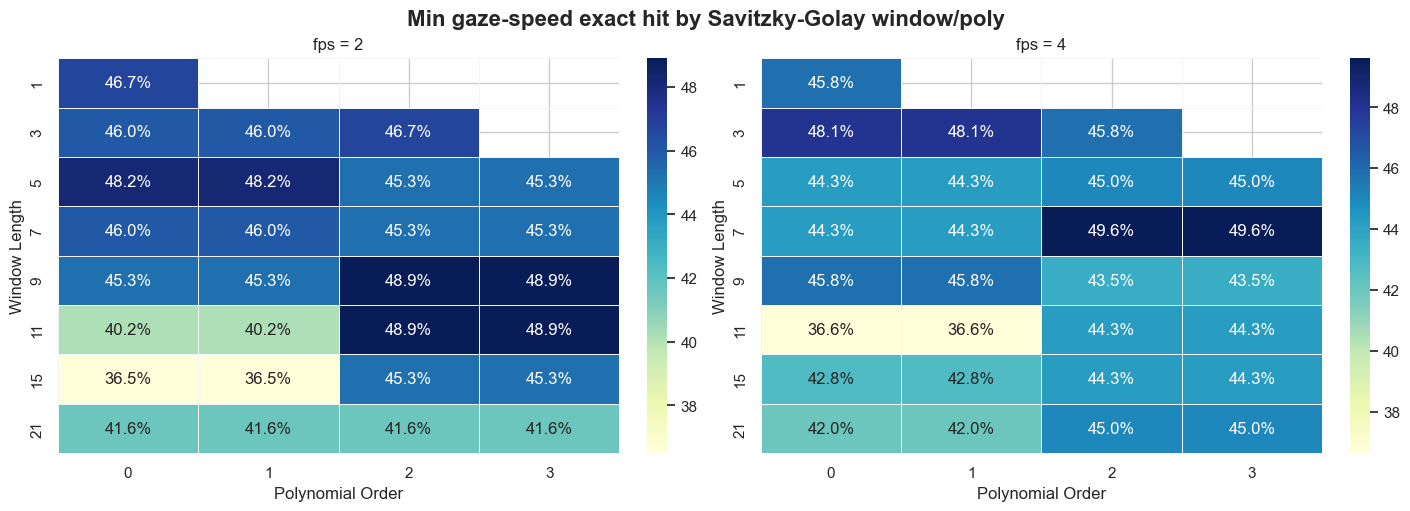

In [4]:
display(Markdown("## Exact Hit Tables"))
for fps in sorted(sweep_df["fps"].unique()):
    display_metric_table(sweep_df, int(fps), "gaze_exact", percent=True)

plot_metric_heatmaps(sweep_df, "gaze_exact", percent=True)


## Additional Metrics

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,59.1%,-,-,-
3,53.3%,53.3%,59.1%,-
5,51.8%,51.8%,52.5%,52.5%
7,52.5%,52.5%,50.4%,50.4%
9,51.1%,51.1%,53.3%,53.3%
11,53.3%,53.3%,54.0%,54.0%
15,43.1%,43.1%,52.5%,52.5%
21,49.6%,50.4%,51.1%,51.1%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,58.0%,-,-,-
3,55.7%,55.7%,58.0%,-
5,53.4%,53.4%,53.4%,53.4%
7,51.1%,51.1%,55.7%,55.7%
9,54.2%,54.2%,51.9%,51.9%
11,51.9%,51.9%,51.9%,51.9%
15,48.9%,48.9%,51.9%,51.9%
21,48.9%,48.9%,55.7%,55.7%


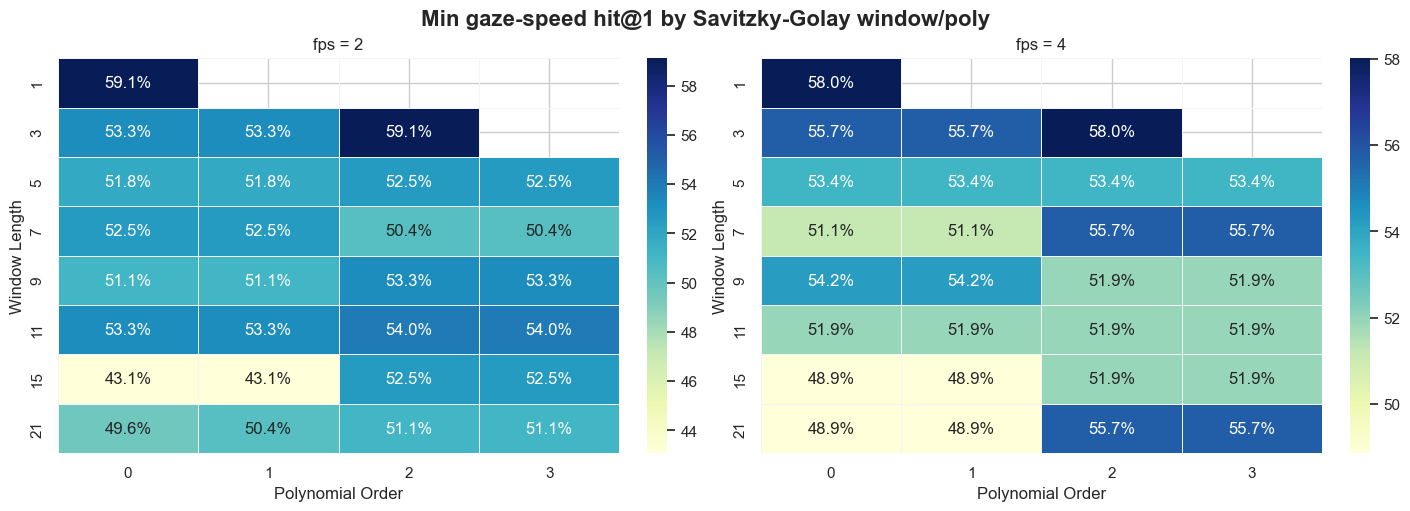

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,22.5%,-,-,-
3,22.5%,22.5%,22.5%,-
5,22.5%,22.5%,22.5%,22.5%
7,21.1%,21.1%,23.9%,23.9%
9,22.5%,22.5%,23.9%,23.9%
11,16.9%,16.9%,25.4%,25.4%
15,18.3%,18.3%,21.1%,21.1%
21,18.3%,18.3%,18.3%,18.3%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,20.9%,-,-,-
3,23.9%,23.9%,20.9%,-
5,22.4%,22.4%,23.9%,23.9%
7,20.9%,20.9%,28.4%,28.4%
9,19.4%,19.4%,23.9%,23.9%
11,13.4%,13.4%,22.4%,22.4%
15,20.9%,20.9%,19.4%,19.4%
21,22.4%,22.4%,23.9%,23.9%


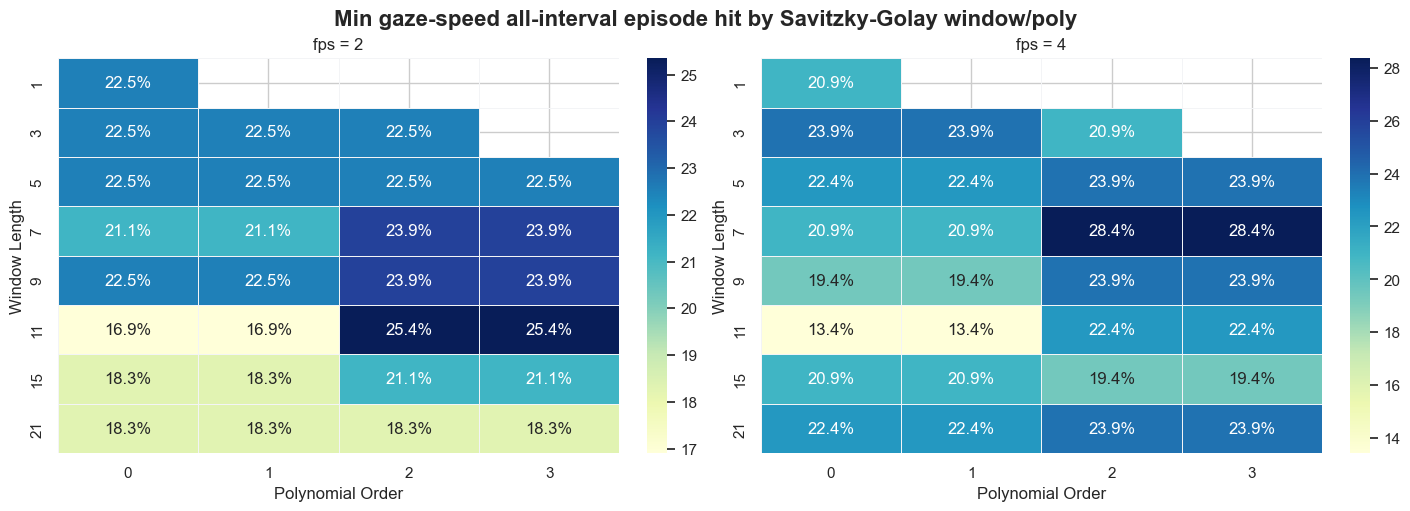

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,45.4%,-,-,-
3,44.7%,44.7%,45.4%,-
5,45.4%,45.4%,43.3%,43.3%
7,43.3%,43.3%,44.0%,44.0%
9,41.8%,41.8%,46.1%,46.1%
11,36.2%,36.2%,46.8%,46.8%
15,34.8%,34.8%,41.8%,41.8%
21,39.7%,39.7%,39.0%,39.0%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_64035/337676412.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,45.1%,-,-,-
3,47.4%,47.4%,45.1%,-
5,42.9%,42.9%,44.4%,44.4%
7,43.6%,43.6%,48.9%,48.9%
9,45.1%,45.1%,42.1%,42.1%
11,36.1%,36.1%,43.6%,43.6%
15,42.1%,42.1%,42.9%,42.9%
21,40.6%,40.6%,44.4%,44.4%


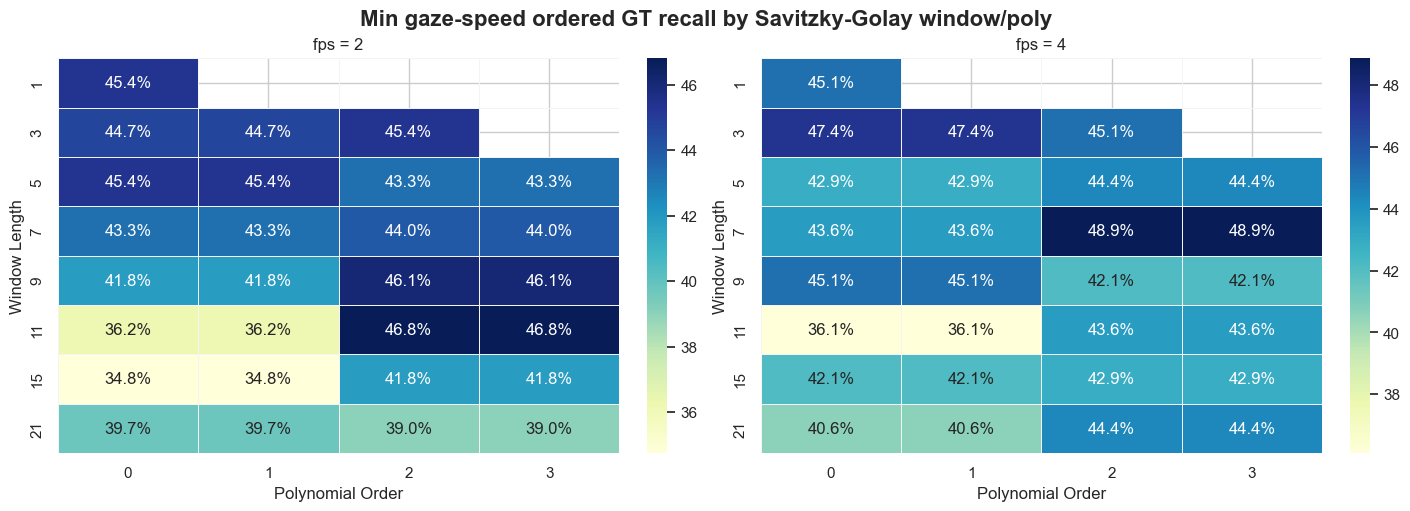

In [5]:
display(Markdown("## Additional Metrics"))
for metric in ["gaze_hit_at_1", "gaze_all_interval_episode", "gaze_ordered_gt_recall"]:
    for fps in sorted(sweep_df["fps"].unique()):
        display_metric_table(sweep_df, int(fps), metric, percent=True)
    plot_metric_heatmaps(sweep_df, metric, percent=True)


In [6]:
display(Markdown("## Best Configs"))
for fps in sorted(sweep_df["fps"].unique()):
    show_top_configs(sweep_df, int(fps), "gaze_exact", top_k=10)


## Best Configs

### fps = 2 / Top 10 configs by Min gaze-speed exact hit

,window,poly,Min gaze-speed exact hit,gaze_hit_at_1,gaze_all_interval_episode,gaze_ordered_gt_recall,gaze_mean_dist
18,11,2,48.9%,54.0%,25.4%,46.8%,3.22
19,11,3,48.9%,54.0%,25.4%,46.8%,3.22
14,9,2,48.9%,53.3%,23.9%,46.1%,3.26
15,9,3,48.9%,53.3%,23.9%,46.1%,3.26
4,5,0,48.2%,51.8%,22.5%,45.4%,3.15
5,5,1,48.2%,51.8%,22.5%,45.4%,3.15
0,1,0,46.7%,59.1%,22.5%,45.4%,2.93
3,3,2,46.7%,59.1%,22.5%,45.4%,2.93
1,3,0,46.0%,53.3%,22.5%,44.7%,2.93
2,3,1,46.0%,53.3%,22.5%,44.7%,2.93


### fps = 4 / Top 10 configs by Min gaze-speed exact hit

,window,poly,Min gaze-speed exact hit,gaze_hit_at_1,gaze_all_interval_episode,gaze_ordered_gt_recall,gaze_mean_dist
38,7,2,49.6%,55.7%,28.4%,48.9%,6.05
39,7,3,49.6%,55.7%,28.4%,48.9%,6.05
29,3,0,48.1%,55.7%,23.9%,47.4%,6.10
30,3,1,48.1%,55.7%,23.9%,47.4%,6.09
28,1,0,45.8%,58.0%,20.9%,45.1%,5.95
31,3,2,45.8%,58.0%,20.9%,45.1%,5.95
40,9,0,45.8%,54.2%,19.4%,45.1%,6.29
41,9,1,45.8%,54.2%,19.4%,45.1%,6.26
54,21,2,45.0%,55.7%,23.9%,44.4%,6.09
55,21,3,45.0%,55.7%,23.9%,44.4%,6.11


In [7]:
output_dir = Path("debug/gaze_savgol_sweep")
for fps in sorted(sweep_df["fps"].unique()):
    matrix = build_metric_matrix(sweep_df, int(fps), "gaze_exact")
    matrix.to_csv(output_dir / f"gemini-3.1-flash-lite-preview_cap_true_gaze_false_gaze_exact_fps{int(fps)}.csv")
print(f"Saved per-fps exact-hit matrices under: {output_dir}")


Saved per-fps exact-hit matrices under: debug/gaze_savgol_sweep
